# Supported vector machine (SVM)

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [2]:
path=r"C:\artificial_intelligence_coarse\sir_git_ai\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-07-completing-classical-ML\datasets\admissions.csv"

In [3]:
df=pd.read_csv(path)

In [4]:
df.head()

,exam1,exam2,admitted
0,76.13,73.79,1
1,49.33,60.89,0
2,39.82,68.46,0
3,20.00,74.84,0
4,59.35,87.94,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   exam1     100 non-null    float64
 1   exam2     100 non-null    float64
 2   admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.describe()

,exam1,exam2,admitted
count,100.000000,100.000000,100.000000
mean,64.244300,66.078700,0.610000
std,15.487057,15.312381,0.490207
min,20.000000,36.100000,0.000000
25%,54.980000,56.337500,0.000000
50%,64.420000,66.440000,1.000000
75%,74.310000,78.550000,1.000000
max,100.000000,100.000000,1.000000


In [7]:
df_c0=df[df['admitted']==0]
df_c1=df[df['admitted']==1]

In [8]:
print(df_c0.shape)

(39, 3)


In [9]:
print(df_c1.shape)

(61, 3)


In [16]:
import seaborn as sns

<Axes: xlabel='exam1', ylabel='exam2'>

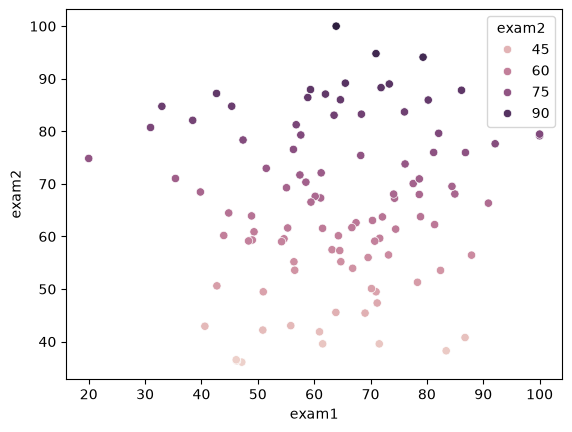

In [19]:
sns.scatterplot(data=df,x=df['exam1'],y=df['exam2'],hue=df['exam2'])

In [21]:
feature=df[["exam1",'exam2']]

In [22]:
feature

,exam1,exam2
0,76.13,73.79
1,49.33,60.89
2,39.82,68.46
3,20.00,74.84
4,59.35,87.94
...,...,...
95,56.55,53.58
96,64.30,60.14
97,64.73,55.20
98,62.00,87.08


In [24]:
y=df['admitted']

In [25]:
xtrain,xtest,ytrain,ytest=train_test_split(df[["exam1",'exam2']],df["admitted"],test_size=0.25,random_state=10)

In [26]:
modelsvc=SVC(C=1,kernel='linear')

In [28]:
modelsvc.fit(xtrain,ytrain)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
predsvc=modelsvc.predict(xtest)

In [32]:
predtra=modelsvc.predict(xtrain)

In [33]:
accuracy_score(ytrain,predtra)

0.7866666666666666

In [35]:
modelsvc.score(xtest,ytest)

0.8

In [36]:
modelsvc.coef_

array([[0.09348425, 0.09194977]])

In [37]:
modelsvc.intercept_

array([-11.03905528])

In [49]:
w1=modelsvc.coef_[0,0]
w2=modelsvc.coef_[0,1]
b=modelsvc.intercept_[0]
x1=np.array([df.exam1.min(),df.exam1.max()])

In [50]:
x1

array([ 20., 100.])

In [45]:
df.exam1.min()

np.float64(20.0)

In [46]:
df.exam1.max()

np.float64(100.0)

In [47]:
df.exam2.min()

np.float64(36.1)

In [48]:
df.exam2.max()

np.float64(100.0)

In [51]:
x2=-(w1*x1+b)/w2

In [52]:
x2

array([99.72151608, 18.38645201])

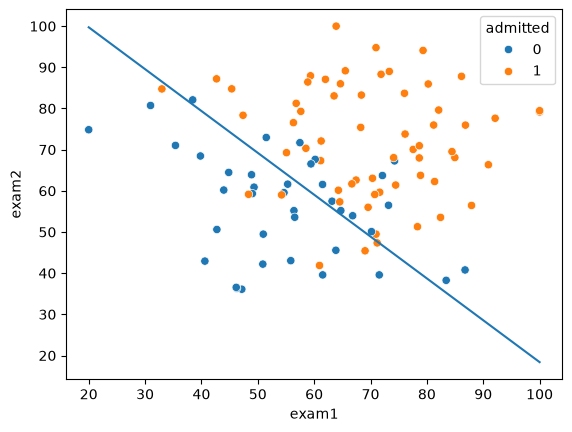

In [56]:
sns.scatterplot(data=df,x=df['exam1'],y=df['exam2'],hue=df['admitted'])
plt.plot(x1,x2)

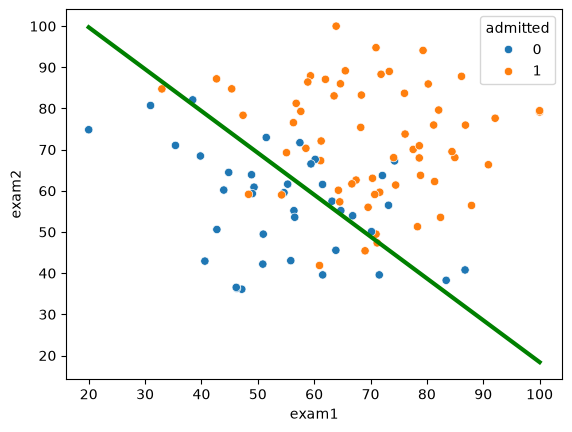

In [59]:
sns.scatterplot(data=df,x='exam1',y='exam2',hue='admitted')
plt.plot(np.array([df.exam1.min(),df.exam1.max()]),-(modelsvc.coef_[0,0]*np.array([df.exam1.min(),df.exam1.max()])+modelsvc.intercept_)/modelsvc.coef_[0,1],c='green',lw=3)

In [67]:
modelsvc2=SVC(kernel='linear',C=1000)

In [68]:
modelsvc2.fit(xtrain,ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [70]:
predsvc2=modelsvc2.predict(xtrain)

In [ ]:
modelsvc2.score(xtrain,ytrain)

0.8

In [74]:
modelsvc2.score(xtest,ytest)

0.76

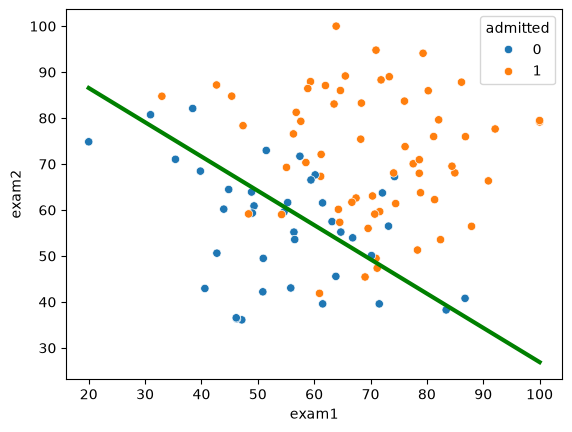

In [76]:
sns.scatterplot(data=df,x='exam1',y='exam2',hue='admitted')
plt.plot(np.array([df.exam1.min(),df.exam1.max()]),-(modelsvc2.coef_[0,0]*np.array([df.exam1.min(),df.exam1.max()])+modelsvc2.intercept_)/modelsvc2.coef_[0,1],c='green',lw=3)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
modellog=LogisticRegression(C=100)

In [62]:
modellog.fit(xtrain,ytrain)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [63]:
predlog=modellog.predict(xtest)

In [64]:
modellog.score(xtest,ytest)

0.8

In [65]:
accuracy_score(ytest,predlog)

0.8